In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage.metrics import mean_squared_error, structural_similarity

Результат загрузки изображения:
Размер изображения: (470, 650)


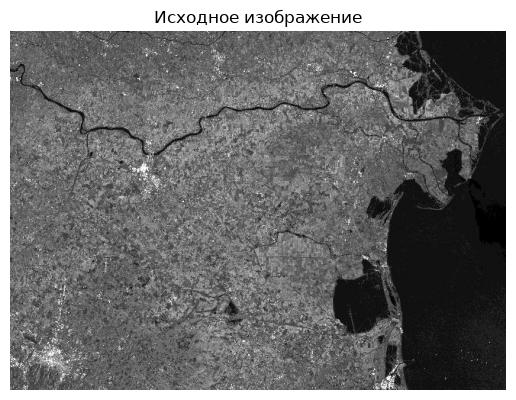

In [2]:
image_gray = cv2.imread('Desktop/sar_my_gray.jpg', cv2.IMREAD_GRAYSCALE)

print('Результат загрузки изображения:')
print('Размер изображения:', image_gray.shape)

plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')
plt.show()

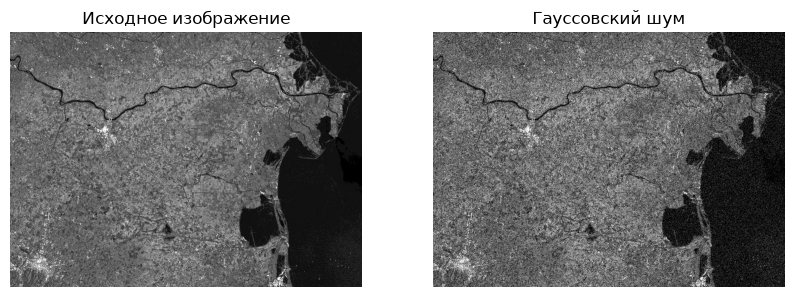

In [3]:
mean = 0
sigma = 25

gaussian_noise = np.random.normal(mean, sigma, image_gray.shape)

gaussian_image = image_gray.astype(np.float32) + gaussian_noise
gaussian_image = np.clip(gaussian_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.show()

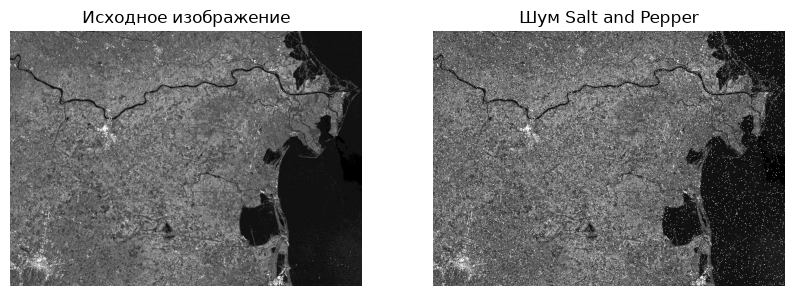

In [4]:
salt_pepper_image = image_gray.copy()

prob = 0.05

random_matrix = np.random.random(image_gray.shape)

salt_pepper_image[random_matrix < prob / 2] = 0
salt_pepper_image[random_matrix > 1 - prob / 2] = 255

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Шум Salt and Pepper')
plt.axis('off')

plt.show()

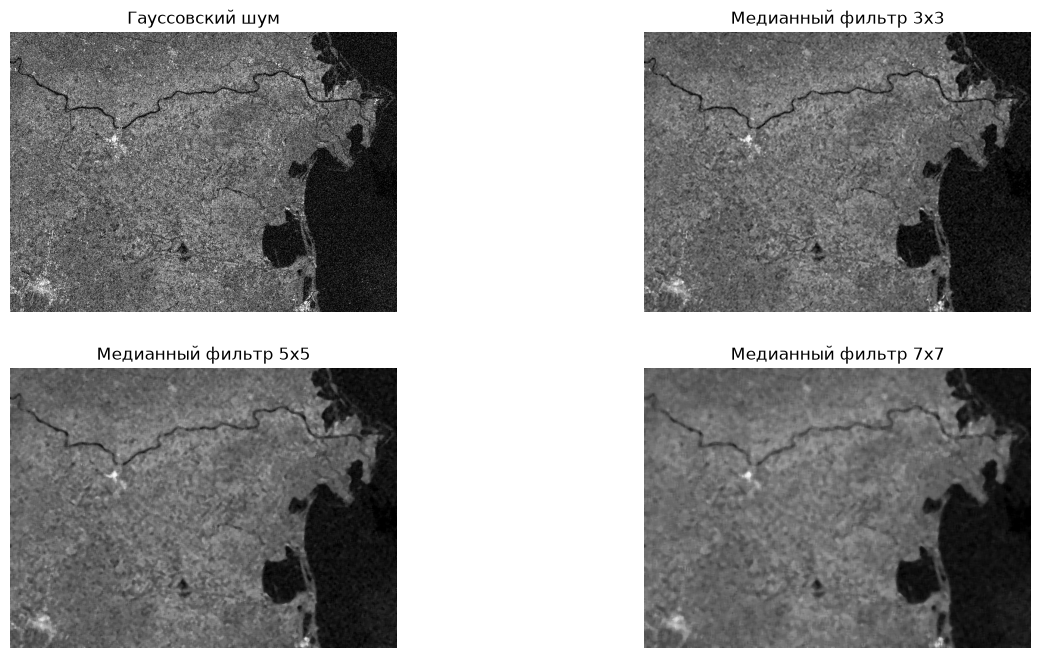

In [7]:
median_3 = cv2.medianBlur(gaussian_image, 3)
median_5 = cv2.medianBlur(gaussian_image, 5)
median_7 = cv2.medianBlur(gaussian_image, 7)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(median_3, cmap='gray')
plt.title('Медианный фильтр 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(median_5, cmap='gray')
plt.title('Медианный фильтр 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_7, cmap='gray')
plt.title('Медианный фильтр 7x7')
plt.axis('off')

plt.show()

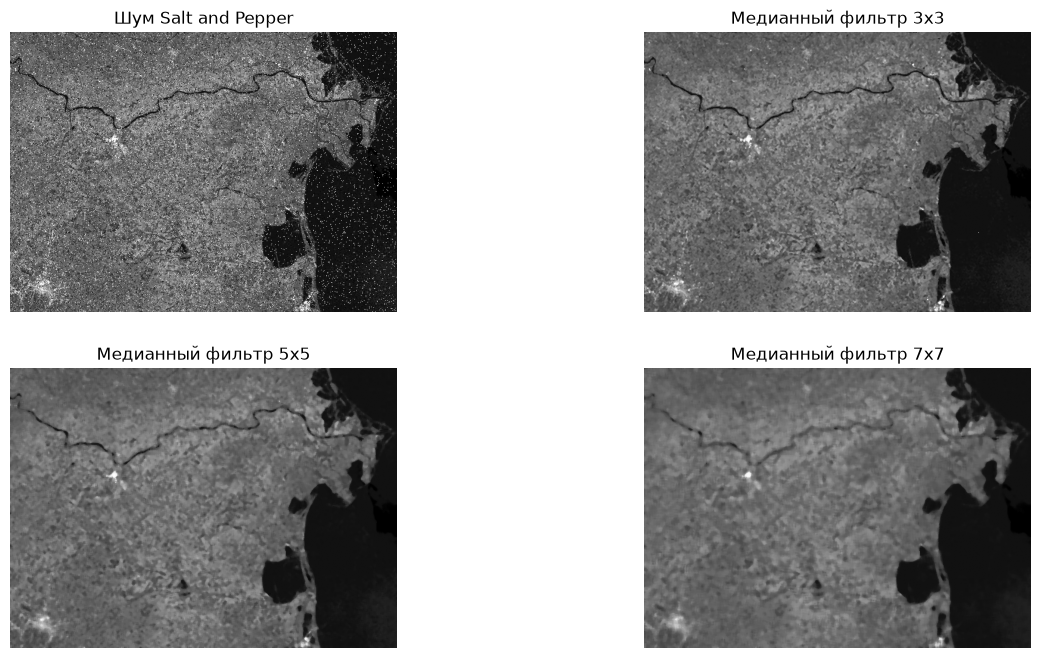

In [8]:
sp_median_3 = cv2.medianBlur(salt_pepper_image, 3)
sp_median_5 = cv2.medianBlur(salt_pepper_image, 5)
sp_median_7 = cv2.medianBlur(salt_pepper_image, 7)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Шум Salt and Pepper')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sp_median_3, cmap='gray')
plt.title('Медианный фильтр 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sp_median_5, cmap='gray')
plt.title('Медианный фильтр 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sp_median_7, cmap='gray')
plt.title('Медианный фильтр 7x7')
plt.axis('off')

plt.show()

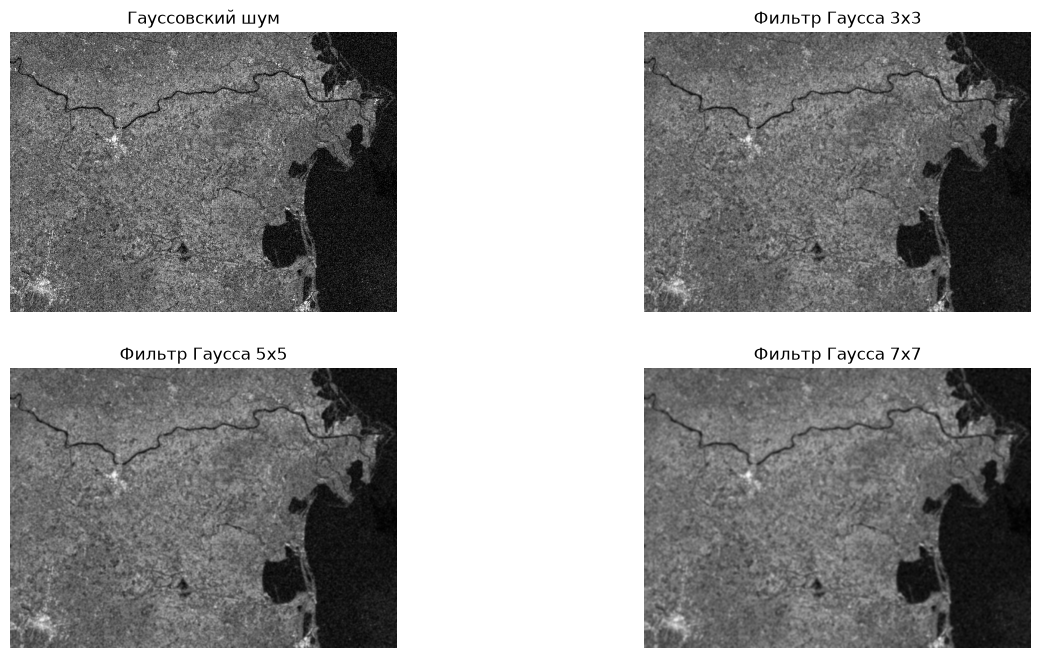

In [9]:
gauss_3 = cv2.GaussianBlur(gaussian_image, (3, 3), 0)
gauss_5 = cv2.GaussianBlur(gaussian_image, (5, 5), 0)
gauss_7 = cv2.GaussianBlur(gaussian_image, (7, 7), 0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gauss_3, cmap='gray')
plt.title('Фильтр Гаусса 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gauss_5, cmap='gray')
plt.title('Фильтр Гаусса 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gauss_7, cmap='gray')
plt.title('Фильтр Гаусса 7x7')
plt.axis('off')

plt.show()

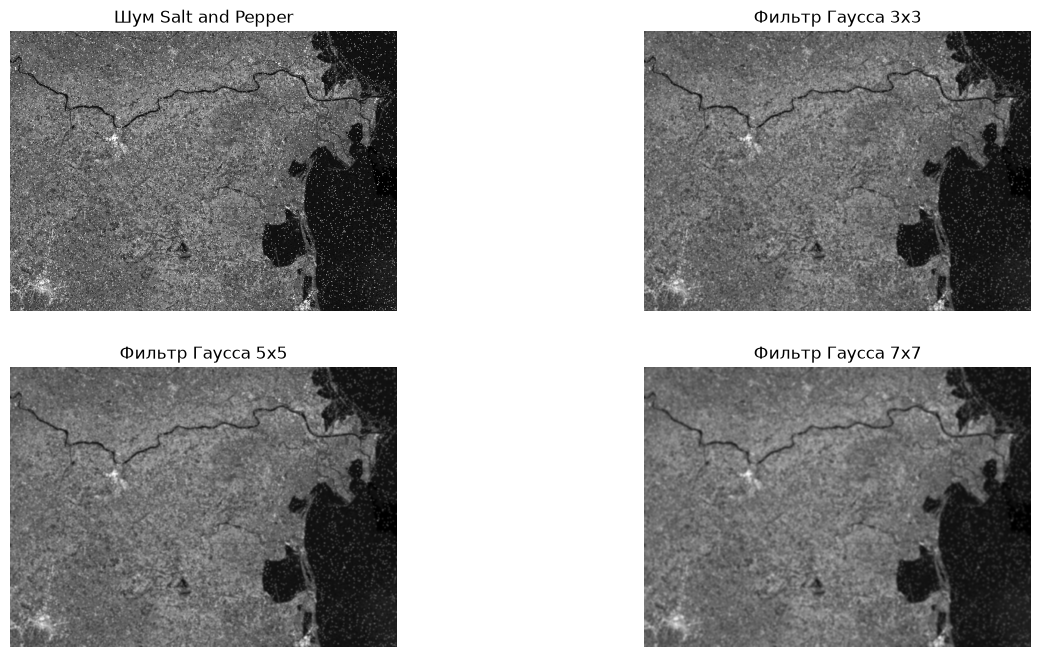

In [10]:
sp_gauss_3 = cv2.GaussianBlur(salt_pepper_image, (3, 3), 0)
sp_gauss_5 = cv2.GaussianBlur(salt_pepper_image, (5, 5), 0)
sp_gauss_7 = cv2.GaussianBlur(salt_pepper_image, (7, 7), 0)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Шум Salt and Pepper')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sp_gauss_3, cmap='gray')
plt.title('Фильтр Гаусса 3x3')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sp_gauss_5, cmap='gray')
plt.title('Фильтр Гаусса 5x5')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sp_gauss_7, cmap='gray')
plt.title('Фильтр Гаусса 7x7')
plt.axis('off')

plt.show()

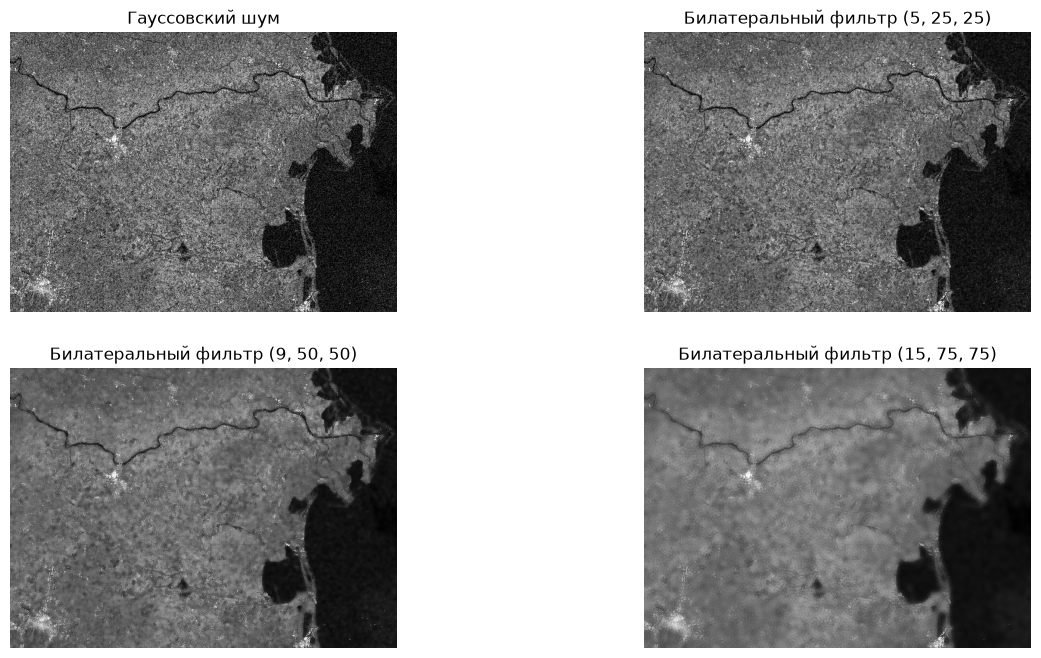

In [14]:
bilateral_1 = cv2.bilateralFilter(gaussian_image, 5, 25, 25)
bilateral_2 = cv2.bilateralFilter(gaussian_image, 9, 50, 50)
bilateral_3 = cv2.bilateralFilter(gaussian_image, 15, 75, 75)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bilateral_1, cmap='gray')
plt.title('Билатеральный фильтр (5, 25, 25)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(bilateral_2, cmap='gray')
plt.title('Билатеральный фильтр (9, 50, 50)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral_3, cmap='gray')
plt.title('Билатеральный фильтр (15, 75, 75)')
plt.axis('off')

plt.show()

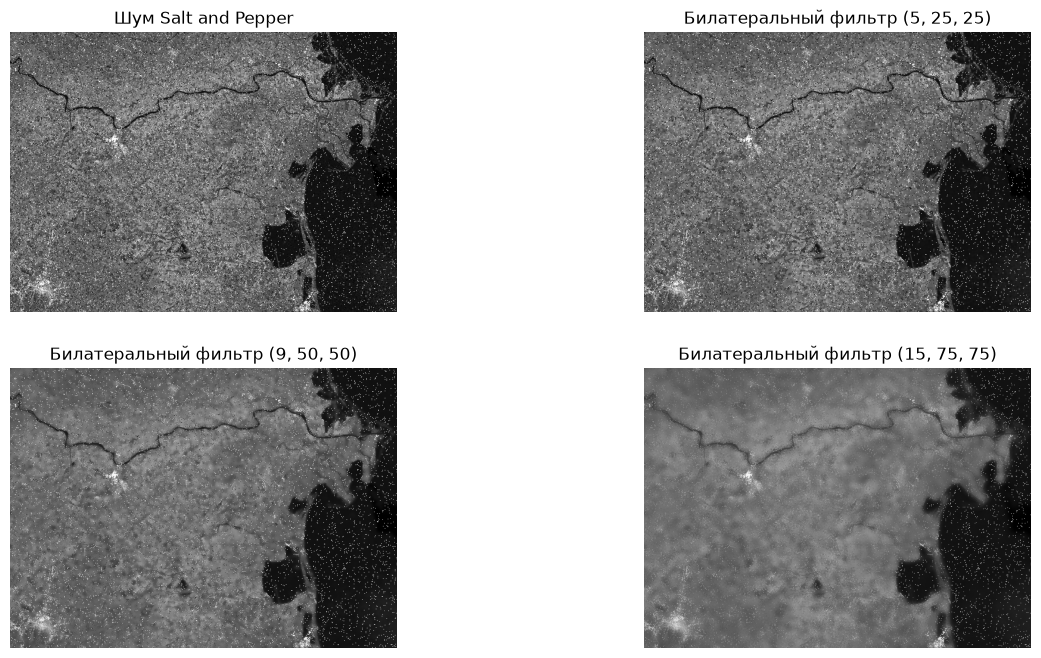

In [15]:
sp_bilateral_1 = cv2.bilateralFilter(salt_pepper_image, 5, 25, 25)
sp_bilateral_2 = cv2.bilateralFilter(salt_pepper_image, 9, 50, 50)
sp_bilateral_3 = cv2.bilateralFilter(salt_pepper_image, 15, 75, 75)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Шум Salt and Pepper')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sp_bilateral_1, cmap='gray')
plt.title('Билатеральный фильтр (5, 25, 25)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sp_bilateral_2, cmap='gray')
plt.title('Билатеральный фильтр (9, 50, 50)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sp_bilateral_3, cmap='gray')
plt.title('Билатеральный фильтр (15, 75, 75)')
plt.axis('off')

plt.show()

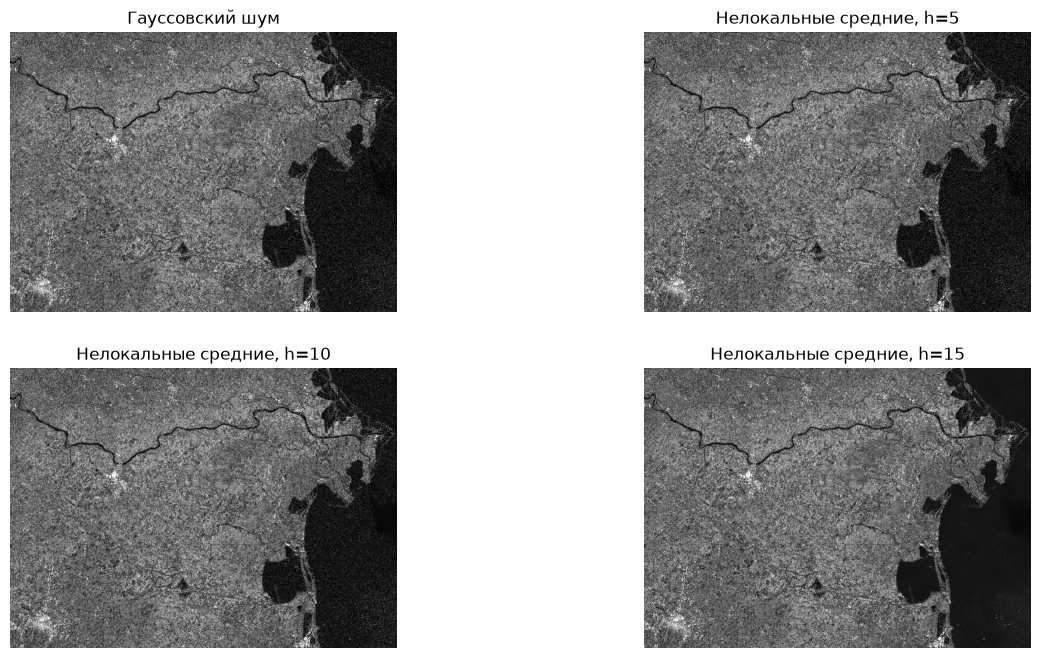

In [16]:
nlm_1 = cv2.fastNlMeansDenoising(gaussian_image, None, 5, 7, 21)
nlm_2 = cv2.fastNlMeansDenoising(gaussian_image, None, 10, 7, 21)
nlm_3 = cv2.fastNlMeansDenoising(gaussian_image, None, 15, 7, 21)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(nlm_1, cmap='gray')
plt.title('Нелокальные средние, h=5')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(nlm_2, cmap='gray')
plt.title('Нелокальные средние, h=10')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(nlm_3, cmap='gray')
plt.title('Нелокальные средние, h=15')
plt.axis('off')

plt.show()

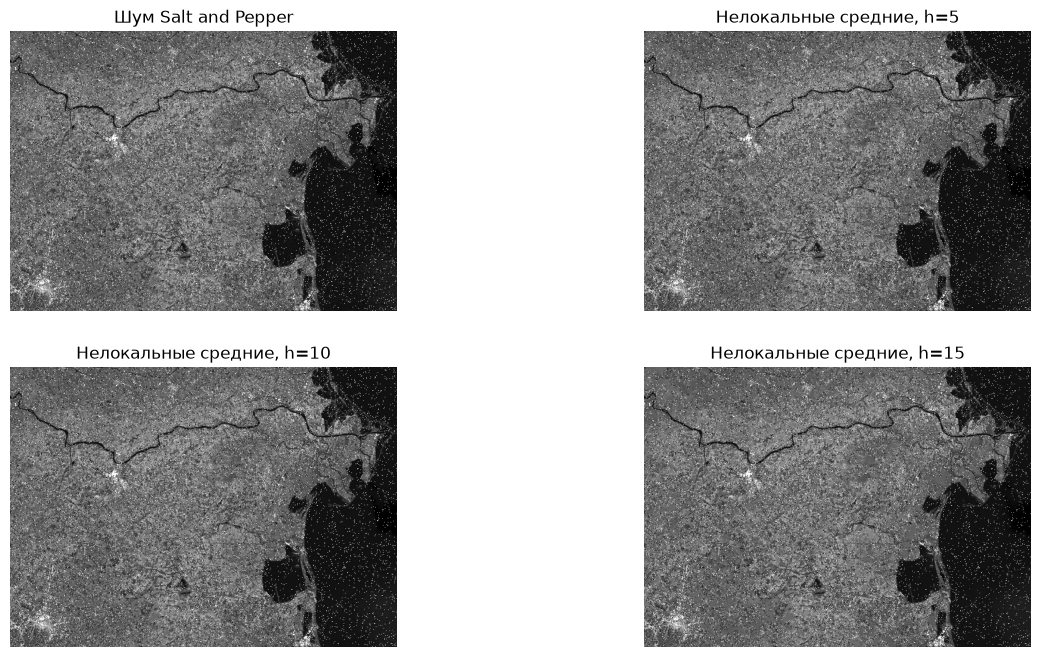

In [18]:
sp_nlm_1 = cv2.fastNlMeansDenoising(salt_pepper_image, None, 5, 7, 21)
sp_nlm_2 = cv2.fastNlMeansDenoising(salt_pepper_image, None, 10, 7, 21)
sp_nlm_3 = cv2.fastNlMeansDenoising(salt_pepper_image, None, 15, 7, 21)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Шум Salt and Pepper')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(sp_nlm_1, cmap='gray')
plt.title('Нелокальные средние, h=5')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(sp_nlm_2, cmap='gray')
plt.title('Нелокальные средние, h=10')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(sp_nlm_3, cmap='gray')
plt.title('Нелокальные средние, h=15')
plt.axis('off')

plt.show()

In [23]:
results_gaussian = {
    'Без фильтра': gaussian_image,
    'Медианный 3x3': median_3,
    'Медианный 5x5': median_5,
    'Медианный 7x7': median_7,
    'Гаусса 3x3': gauss_3,
    'Гаусса 5x5': gauss_5,
    'Гаусса 7x7': gauss_7,
    'Билатеральный (5,25,25)': bilateral_1,
    'Билатеральный (9,50,50)': bilateral_2,
    'Билатеральный (15,75,75)': bilateral_3,
    'Нелокальные средние, h=5': nlm_1,
    'Нелокальные средние, h=10': nlm_2,
    'Нелокальные средние, h=15': nlm_3
}

print('Сравнение фильтров для гауссовского шума:\n')

for name, img in results_gaussian.items():
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)

    print(name)
    print('MSE:', round(mse, 2))
    print('SSIM:', round(ssim, 4))
    print()

Сравнение фильтров для гауссовского шума:

Без фильтра
MSE: 579.11
SSIM: 0.5996

Медианный 3x3
MSE: 543.07
SSIM: 0.4398

Медианный 5x5
MSE: 583.61
SSIM: 0.3558

Медианный 7x7
MSE: 630.97
SSIM: 0.298

Гаусса 3x3
MSE: 377.91
SSIM: 0.5915

Гаусса 5x5
MSE: 437.11
SSIM: 0.519

Гаусса 7x7
MSE: 497.55
SSIM: 0.4429

Билатеральный (5,25,25)
MSE: 351.72
SSIM: 0.6742

Билатеральный (9,50,50)
MSE: 293.87
SSIM: 0.6602

Билатеральный (15,75,75)
MSE: 433.64
SSIM: 0.5037

Нелокальные средние, h=5
MSE: 579.11
SSIM: 0.5996

Нелокальные средние, h=10
MSE: 562.83
SSIM: 0.6083

Нелокальные средние, h=15
MSE: 491.29
SSIM: 0.6977



In [24]:
results_salt_pepper = {
    'Без фильтра': salt_pepper_image,
    'Медианный 3x3': sp_median_3,
    'Медианный 5x5': sp_median_5,
    'Медианный 7x7': sp_median_7,
    'Гаусса 3x3': sp_gauss_3,
    'Гаусса 5x5': sp_gauss_5,
    'Гаусса 7x7': sp_gauss_7,
    'Билатеральный (5,25,25)': sp_bilateral_1,
    'Билатеральный (9,50,50)': sp_bilateral_2,
    'Билатеральный (15,75,75)': sp_bilateral_3,
    'Нелокальные средние, h=5': sp_nlm_1,
    'Нелокальные средние, h=10': sp_nlm_2,
    'Нелокальные средние, h=15': sp_nlm_3
}

print('Сравнение фильтров для шума Salt and Pepper:\n')

for name, img in results_salt_pepper.items():
    mse = mean_squared_error(image_gray, img)
    ssim = structural_similarity(image_gray, img)

    print(name)
    print('MSE:', round(mse, 2))
    print('SSIM:', round(ssim, 4))
    print()

Сравнение фильтров для шума Salt and Pepper:

Без фильтра
MSE: 1009.06
SSIM: 0.5758

Медианный 3x3
MSE: 445.25
SSIM: 0.5645

Медианный 5x5
MSE: 546.32
SSIM: 0.413

Медианный 7x7
MSE: 613.6
SSIM: 0.328

Гаусса 3x3
MSE: 450.45
SSIM: 0.5395

Гаусса 5x5
MSE: 480.15
SSIM: 0.4719

Гаусса 7x7
MSE: 524.66
SSIM: 0.4061

Билатеральный (5,25,25)
MSE: 1064.97
SSIM: 0.4888

Билатеральный (9,50,50)
MSE: 859.96
SSIM: 0.4124

Билатеральный (15,75,75)
MSE: 666.79
SSIM: 0.3528

Нелокальные средние, h=5
MSE: 1008.89
SSIM: 0.5757

Нелокальные средние, h=10
MSE: 1009.38
SSIM: 0.5731

Нелокальные средние, h=15
MSE: 974.25
SSIM: 0.5681



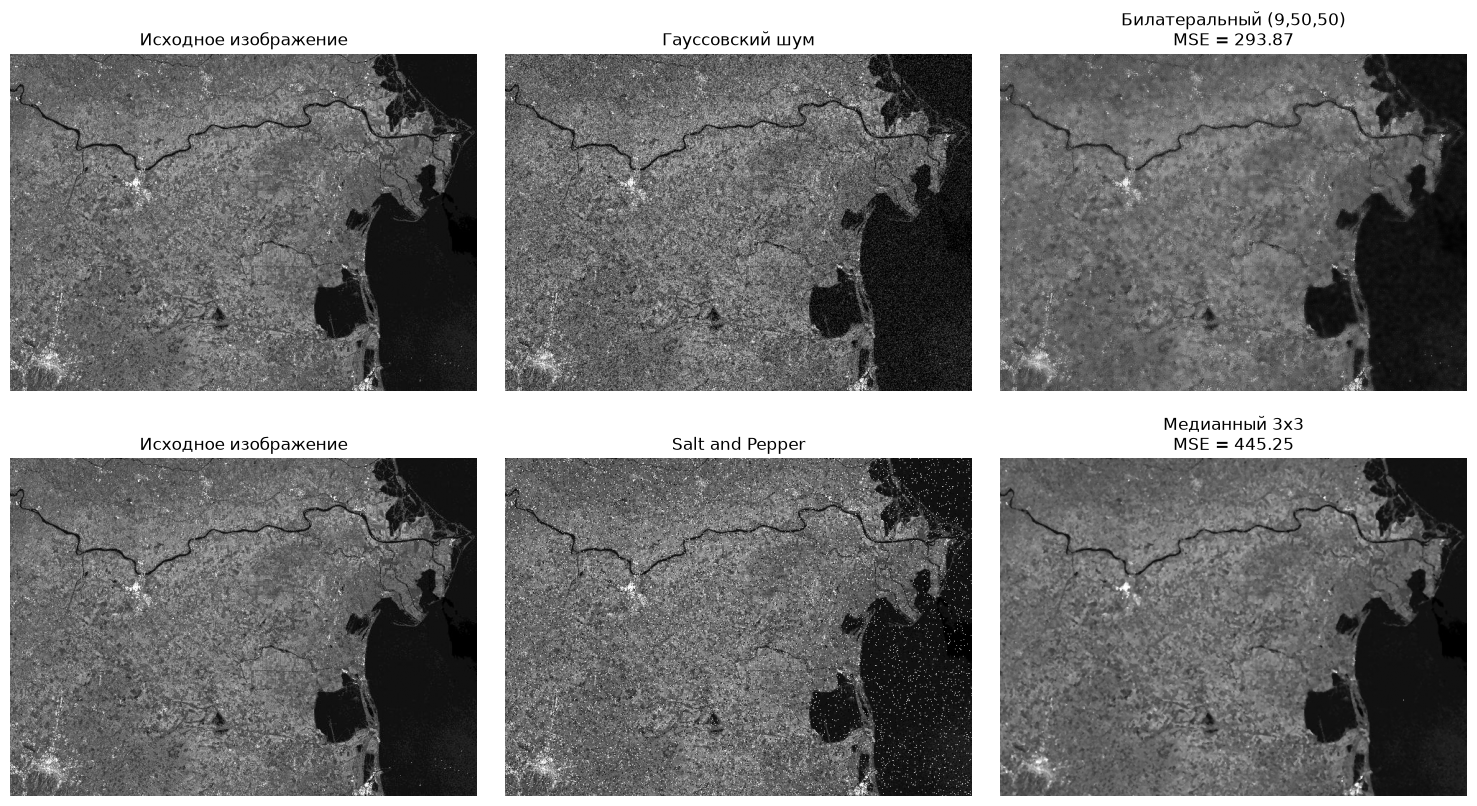

In [25]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gaussian_image, cmap='gray')
plt.title('Гауссовский шум')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bilateral_2, cmap='gray')
plt.title('Билатеральный (9,50,50)\nMSE = 293.87')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(salt_pepper_image, cmap='gray')
plt.title('Salt and Pepper')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(sp_median_3, cmap='gray')
plt.title('Медианный 3x3\nMSE = 445.25')
plt.axis('off')

plt.tight_layout(h_pad=4)
plt.show()